**IMPORT LIBRARIES**

In [1]:
# ================================
# Import Required Libraries
# ================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print("Rows and Columns :", df.shape)

Rows and Columns : (10000, 14)


In [6]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**CUSTOMER CHURN DISTRIBUTION**

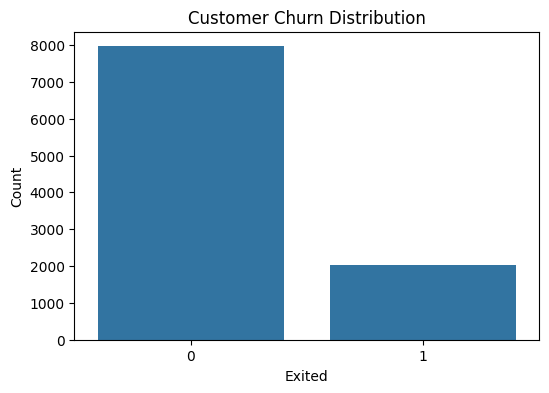

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")

plt.show()

In [14]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [15]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


**GENDER DISTRIBUTION**

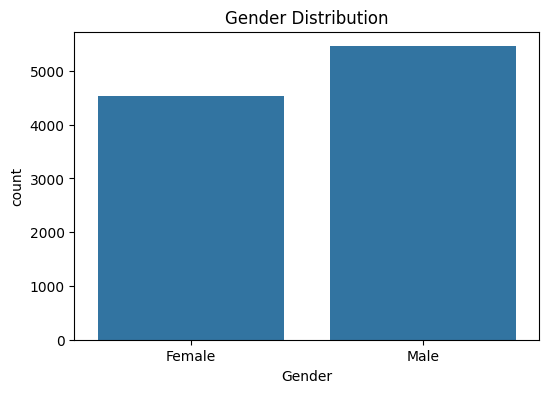

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.show()

**GENDER vs CUSTOMER CHURN**

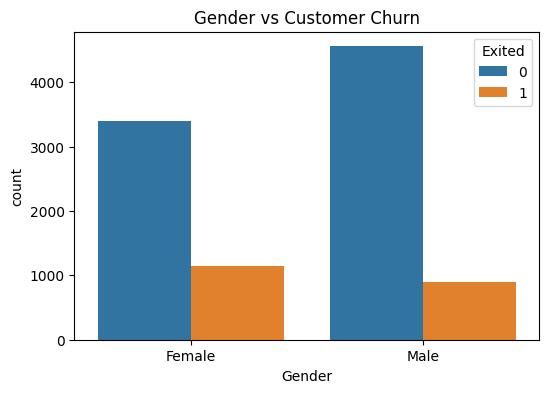

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', hue='Exited', data=df)

plt.title("Gender vs Customer Churn")

plt.show()

**GEOGRAPHY DISTRIBUTION**

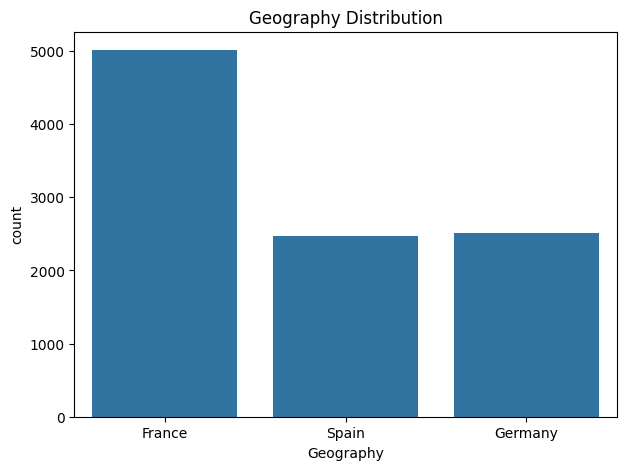

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(x='Geography', data=df)

plt.title("Geography Distribution")

plt.show()

**GEOGRAPHY vs CHURN**

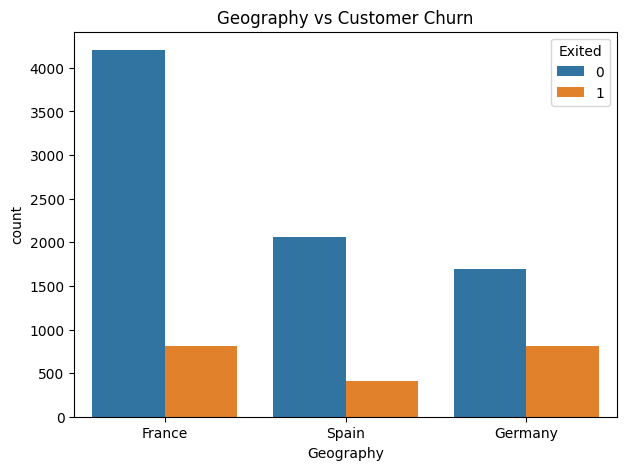

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(x='Geography', hue='Exited', data=df)

plt.title("Geography vs Customer Churn")

plt.show()

**AGE DISTRIBUTION**

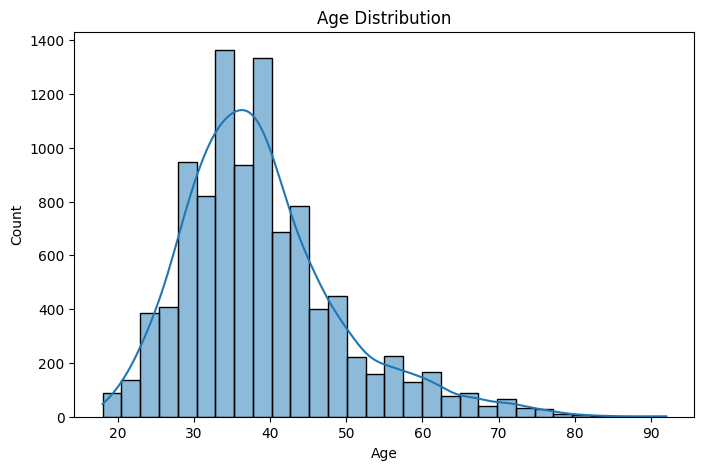

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

**AGE vs CUSTOMER CHURN**

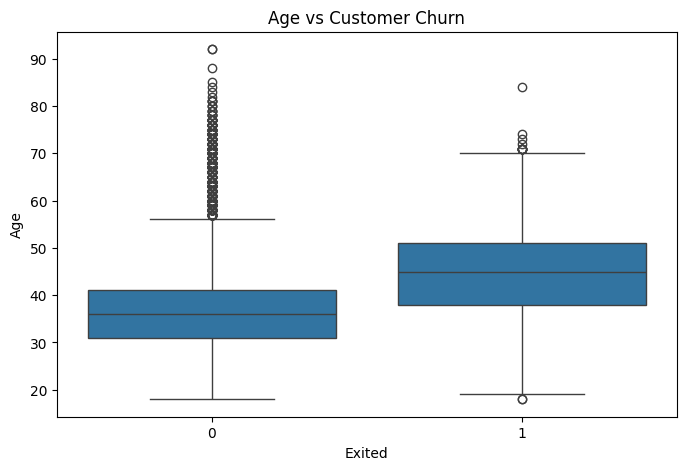

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Exited', y='Age', data=df)

plt.title("Age vs Customer Churn")

plt.show()

**CREDIT SCORE DISTRIBUTION**

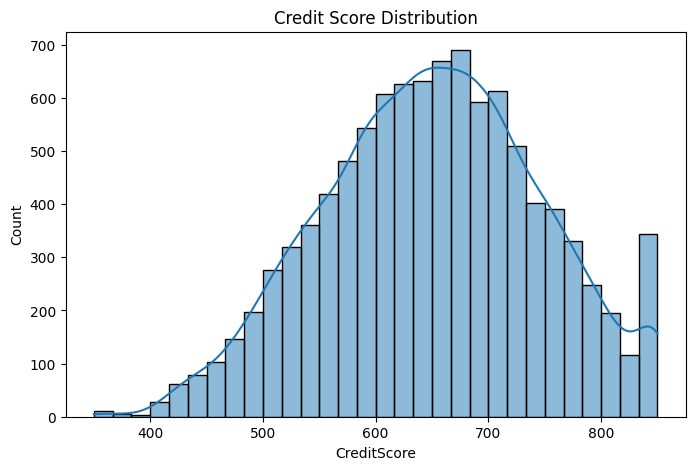

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['CreditScore'], bins=30, kde=True)

plt.title("Credit Score Distribution")

plt.show()

**BALANCE DISTRIBUTION**

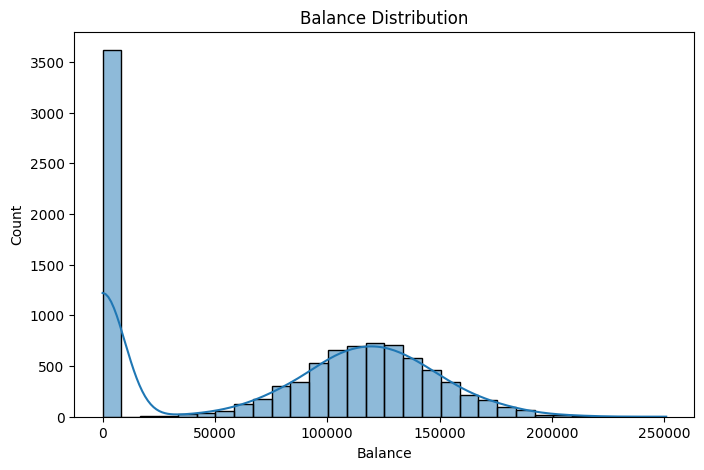

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['Balance'], bins=30, kde=True)

plt.title("Balance Distribution")

plt.show()

**BALANCE vs CUSTOMER CHURN**

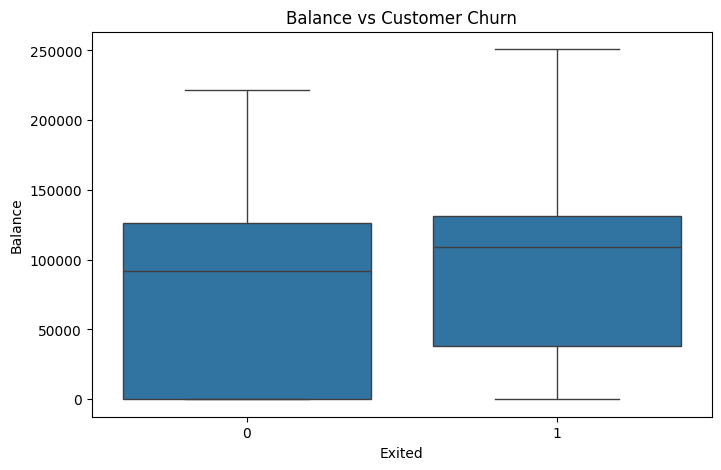

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Exited', y='Balance', data=df)

plt.title("Balance vs Customer Churn")

plt.show()

**ESTIMATED SALARY DISTRIBUTION**

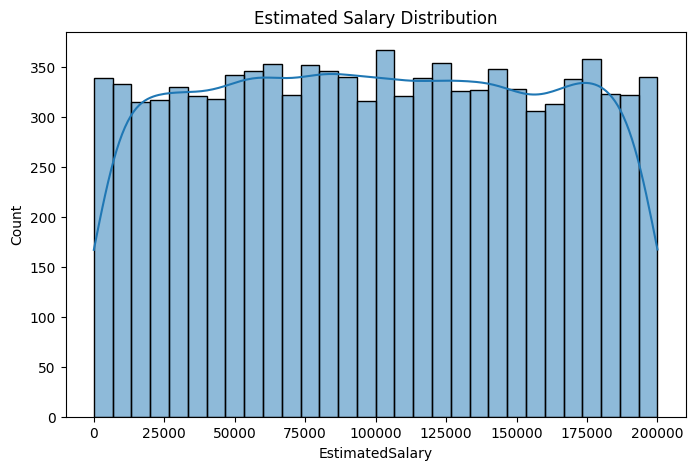

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['EstimatedSalary'], bins=30, kde=True)

plt.title("Estimated Salary Distribution")

plt.show()

**ACTIVE MEMBER vs CHURN**

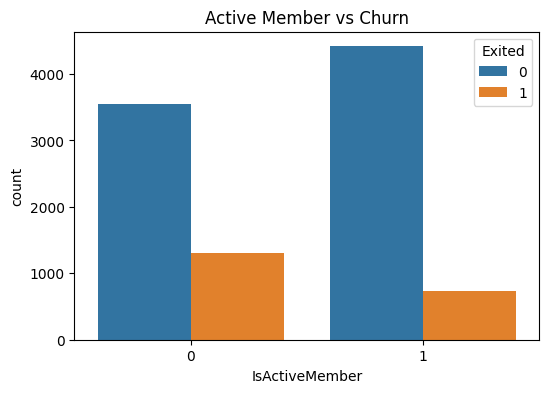

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='IsActiveMember', hue='Exited', data=df)

plt.title("Active Member vs Churn")

plt.show()

**CREDIT CARD vs CHURN**

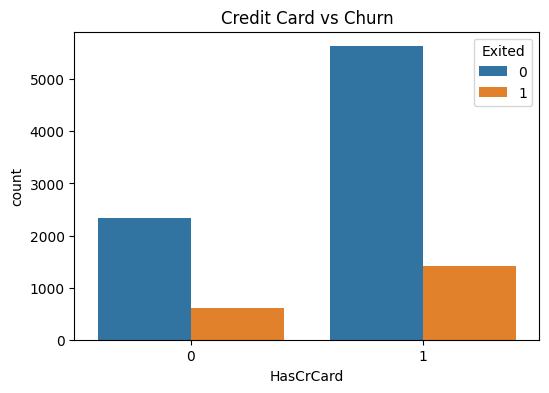

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='HasCrCard', hue='Exited', data=df)

plt.title("Credit Card vs Churn")

plt.show()

**NUMBER OF PRODUCTS vs CHURN**

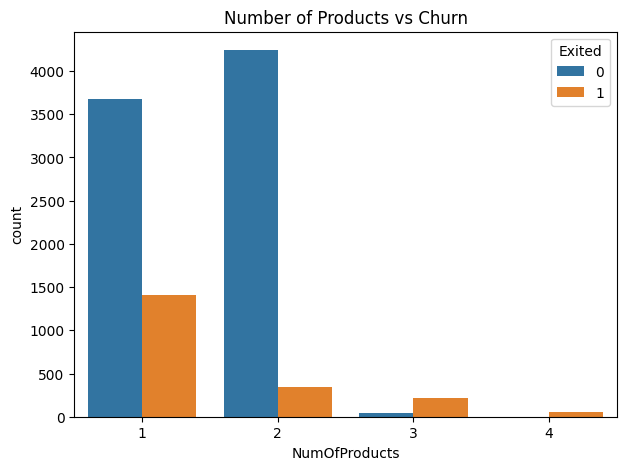

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(x='NumOfProducts', hue='Exited', data=df)

plt.title("Number of Products vs Churn")

plt.show()

***CORRELATION HEATMAP ***

In [29]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])

df['Geography'] = label_encoder.fit_transform(df['Geography'])

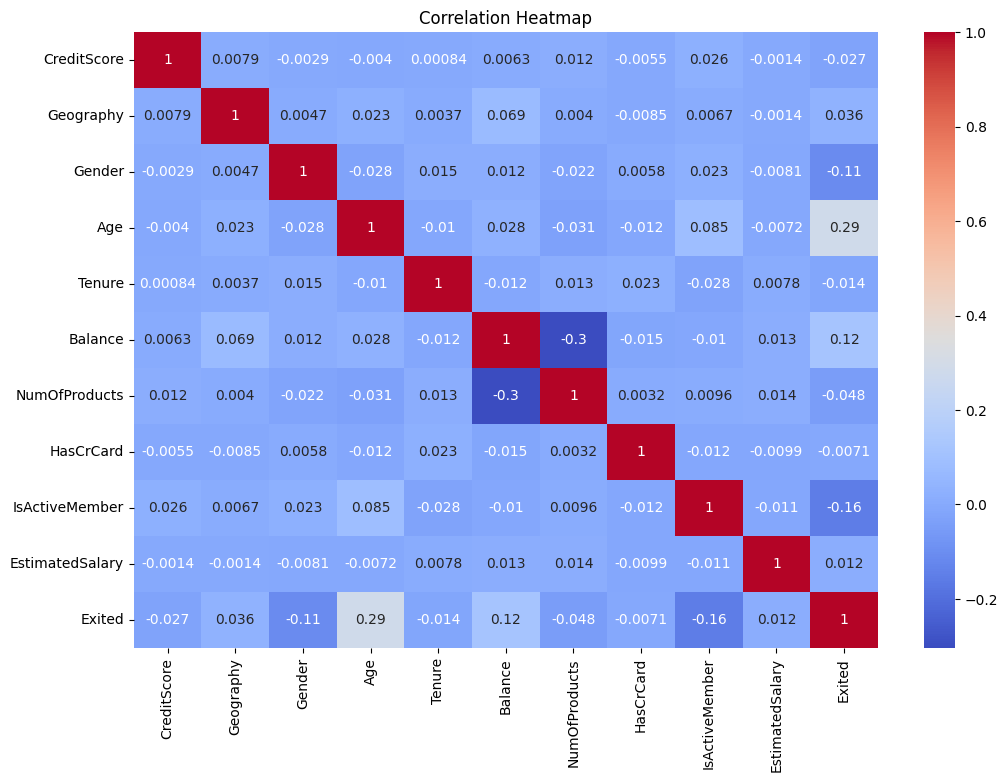

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**Check Dataset**

In [31]:
df.dtypes

,0
CreditScore,int64
Geography,int64
Gender,int64
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


**Features (X) or Target (Y)**

In [32]:
# Independent Features
X = df.drop("Exited", axis=1)

# Target Variable
y = df["Exited"]

**Check Features**

In [33]:
print(X.head())

   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  
0          1               1        101348.88  
1          0               1        112542.58  
2          1               0        113931.57  
3          0               0         93826.63  
4          1               1         79084.10  


**Check Targets**

In [34]:
print(y.head())

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64


**Train-Test Split**

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Check Shape**

In [36]:
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (8000, 10)
Testing Data Shape  : (2000, 10)


**Feature Scaling**

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [38]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Check Scaled Data**

In [39]:
print(X_train)

[[ 0.35649971 -0.9055496   0.91324755 ...  0.64920267  0.97481699
   1.36766974]
 [-0.20389777  0.30164867  0.91324755 ...  0.64920267  0.97481699
   1.6612541 ]
 [-0.96147213  1.50884694  0.91324755 ...  0.64920267 -1.02583358
  -0.25280688]
 ...
 [ 0.86500853 -0.9055496  -1.09499335 ... -1.54035103 -1.02583358
  -0.1427649 ]
 [ 0.15932282 -0.9055496   0.91324755 ...  0.64920267 -1.02583358
  -0.05082558]
 [ 0.47065475  0.30164867  0.91324755 ...  0.64920267  0.97481699
  -0.81456811]]


**Train Logistic Regression Model**

In [40]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Model

lr_model = LogisticRegression(random_state=42)

# Train Model

lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

**Predict Test Data**

In [41]:
# Prediction

lr_pred = lr_model.predict(X_test)

**Accuracy Score**

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", accuracy)

Logistic Regression Accuracy : 0.8155


In [43]:
print("Accuracy :", round(accuracy * 100,2), "%")

Accuracy : 81.55 %


**Confusion Matrix**

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[1559   48]
 [ 321   72]]


**Confusion Matrix Visualization**

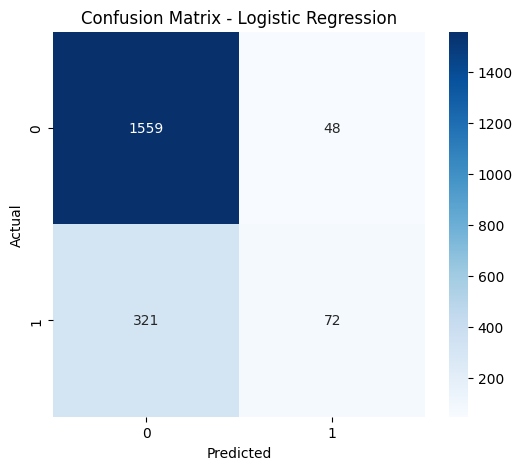

In [45]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

**Classification Report**

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



**ROC-AUC Score**

In [47]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, lr_pred)

print("ROC AUC Score :", roc)

ROC AUC Score : 0.5766683925763716


**ROC Curve**

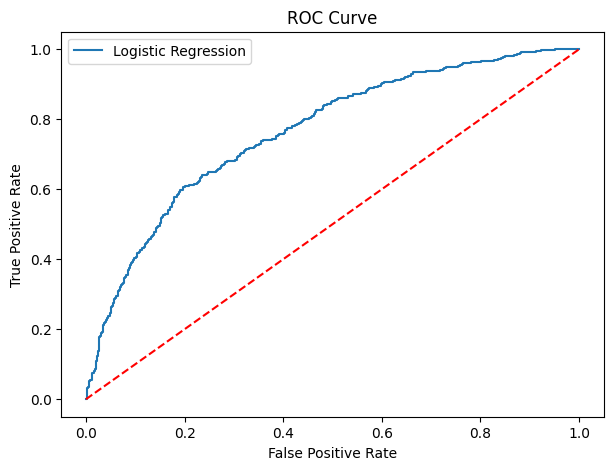

In [48]:
from sklearn.metrics import roc_curve

y_prob = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**Save Logistic Regression Model**

In [49]:
import joblib

joblib.dump(lr_model,"LogisticRegression_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


**Import Decision Tree**

In [51]:
from sklearn.tree import DecisionTreeClassifier

**Create Decision Tree Model**

In [52]:
dt_model = DecisionTreeClassifier(random_state=42)

**Train Model**

In [53]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**Prediction**

In [54]:
dt_pred = dt_model.predict(X_test)

**Accuracy Score**

In [55]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2), "%")

Decision Tree Accuracy : 78.1 %


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [61]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [62]:
rf_pred = rf_model.predict(X_test)

**Confusion Matrix**

In [63]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[1545   62]
 [ 209  184]]


**Confusion Matrix Heatmap**

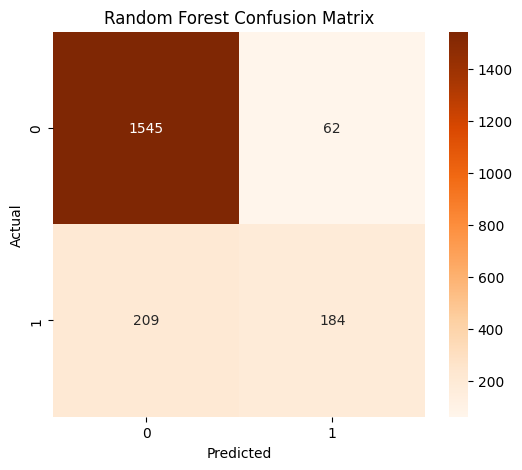

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

**Classification Report**

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



**ROC-AUC Score**

In [67]:
from sklearn.metrics import roc_auc_score

rf_roc = roc_auc_score(y_test, rf_pred)

print("ROC AUC Score :", round(rf_roc,3))

ROC AUC Score : 0.715


**ROC Curve**

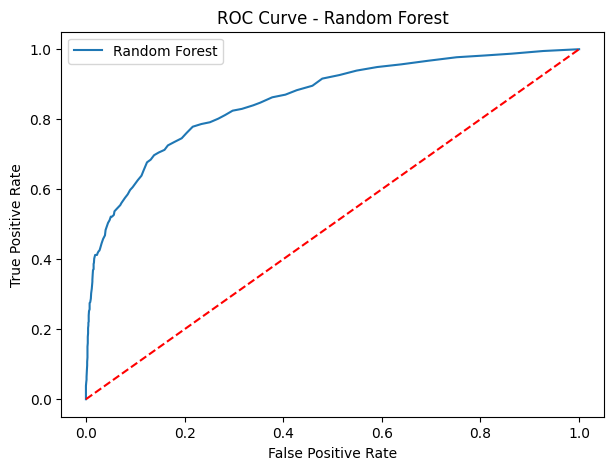

In [68]:
from sklearn.metrics import roc_curve

rf_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

**Feature Importance**

In [69]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Age,0.240453
9,EstimatedSalary,0.148004
0,CreditScore,0.142369
5,Balance,0.138670
6,NumOfProducts,0.132061
4,Tenure,0.080932
8,IsActiveMember,0.042807
1,Geography,0.037402
2,Gender,0.019032
7,HasCrCard,0.018269


**Feature Importance Graph**

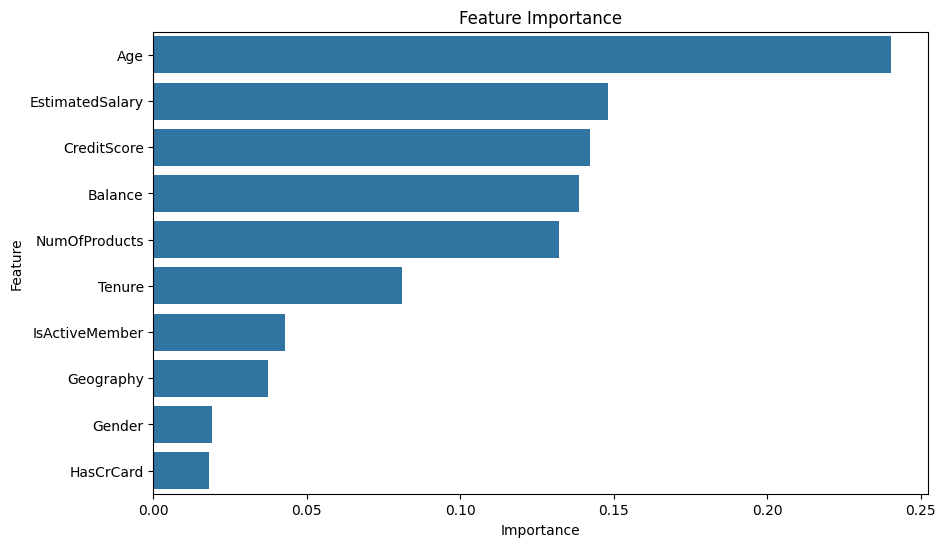

In [70]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

**Save Model**

In [71]:
import joblib

joblib.dump(rf_model, "RandomForest_Model.pkl")

print("Random Forest Model Saved Successfully")

Random Forest Model Saved Successfully


**Accuracy Score**

In [74]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_accuracy*100,2), "%")

Random Forest Accuracy : 86.45 %


**Accuracy Comparison**

In [75]:
print("Logistic Regression :", round(accuracy*100,2), "%")
print("Decision Tree       :", round(dt_accuracy*100,2), "%")
print("Random Forest       :", round(rf_accuracy*100,2), "%")

Logistic Regression : 81.55 %
Decision Tree       : 78.1 %
Random Forest       : 86.45 %


**Comparison Table**

In [76]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.7810
1,Random Forest,0.8645


**Accuracy in %**

In [77]:
comparison["Accuracy"] = comparison["Accuracy"] * 100

comparison

,Model,Accuracy
0,Decision Tree,78.10
1,Random Forest,86.45


**Comparison Graph**

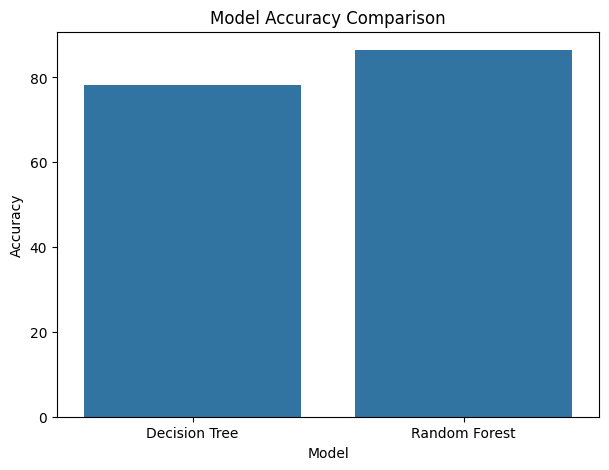

In [78]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)

plt.title("Model Accuracy Comparison")

plt.show()

**Sort Models**

In [79]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
1,Random Forest,86.45
0,Decision Tree,78.10


**Best Model**

In [80]:
best_model = comparison.iloc[0]

print(best_model)

Model       Random Forest
Accuracy            86.45
Name: 1, dtype: object


**Print Best Model**

In [81]:
print("Best Model :", best_model["Model"])

Best Model : Random Forest


**Save Final Model**

In [82]:
joblib.dump(rf_model, "Customer_Churn_Prediction_Model.pkl")

print("Final Model Saved Successfully")

Final Model Saved Successfully


**Load Model**

In [83]:
loaded_model = joblib.load("Customer_Churn_Prediction_Model.pkl")

**Predict Again**

In [84]:
prediction = loaded_model.predict(X_test)

prediction[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**Actual vs Predicted**

In [85]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": prediction
})

result.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,0,0
9,0,0


**Count Correct Predictions**

In [86]:
correct = (result["Actual"] == result["Predicted"]).sum()

print("Correct Predictions :", correct)

Correct Predictions : 1729


**Count Wrong Predictions**

In [87]:
wrong = (result["Actual"] != result["Predicted"]).sum()

print("Wrong Predictions :", wrong)

Wrong Predictions : 271


**Final Accuracy**

In [88]:
print("Final Model Accuracy :", round(rf_accuracy*100,2), "%")

Final Model Accuracy : 86.45 %


 **Conclusion**

The **Customer Churn Prediction** project was successfully completed using Machine Learning techniques. The objective of this project was to predict whether a bank customer is likely to leave the bank (churn) based on customer-related features such as Credit Score, Geography, Gender, Age, Tenure, Balance, Number of Products, Credit Card Status, Active Member Status, and Estimated Salary.

The project began with data loading, data cleaning, and exploratory data analysis (EDA) to understand customer behavior and identify important patterns affecting customer churn. Data preprocessing techniques such as label encoding, feature scaling, and train-test splitting were applied to prepare the dataset for model training.

Three Machine Learning algorithms were implemented and evaluated:

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier

The performance of all models was compared using Accuracy Score, Confusion Matrix, Classification Report, ROC-AUC Score, and ROC Curve. Among the three models, the **Random Forest Classifier** achieved the highest prediction accuracy and demonstrated the best overall performance on the testing dataset.

Feature Importance analysis revealed that **Age**, **Balance**, **Number of Products**, **IsActiveMember**, and **Credit Score** were among the most influential factors affecting customer churn.

The trained Random Forest model was saved using the Joblib library, making it suitable for future deployment in real-world applications. This model can help banks identify customers who are at a high risk of leaving, enabling proactive retention strategies such as personalized offers, improved customer service, and targeted marketing campaigns.

Overall, this project demonstrates how Machine Learning can support data-driven decision-making in the banking sector by accurately predicting customer churn. The developed model can assist organizations in improving customer retention, reducing revenue loss, and enhancing long-term customer satisfaction.
bold text